In [5]:
import pandas as pd
df = pd.read_csv("synthetic_fraud_dataset.csv")

In [6]:
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [7]:
df.tail()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
9995,1076,482,58.366442,POS,Clothing,DE,12,0.066366,0.086344,0
9996,4995,904,139.502160,POS,Travel,DE,13,0.119014,0.285680,0
9997,3485,527,71.012122,Online,Travel,TR,8,0.119204,0.262262,0
9998,7922,771,21.031405,QR,Grocery,UK,12,0.027088,0.295243,0
9999,6451,429,54.028632,ATM,Electronics,DE,11,0.096438,0.042823,0


In [8]:
df.shape

(10000, 10)

In [9]:
df.info

<bound method DataFrame.info of       transaction_id  user_id       amount transaction_type merchant_category  \
0               9608      363  4922.587542              ATM            Travel   
1                456      692    48.018303               QR              Food   
2               4747      587   136.881960           Online            Travel   
3               6934      445    80.534719              POS          Clothing   
4               1646      729   120.041158           Online           Grocery   
...              ...      ...          ...              ...               ...   
9995            1076      482    58.366442              POS          Clothing   
9996            4995      904   139.502160              POS            Travel   
9997            3485      527    71.012122           Online            Travel   
9998            7922      771    21.031405               QR           Grocery   
9999            6451      429    54.028632              ATM       Electronics

In [10]:
df.isnull().sum()

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df["is_fraud"].value_counts()

is_fraud
0    9500
1     500
Name: count, dtype: int64

In [13]:
df["is_fraud"].value_counts(normalize=True)*100

is_fraud
0    95.0
1     5.0
Name: proportion, dtype: float64

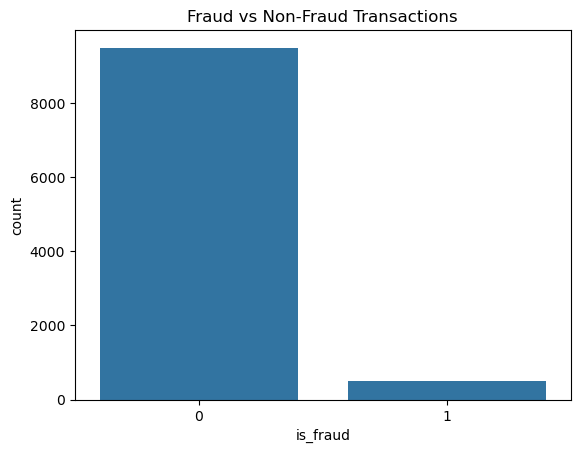

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_fraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [15]:
pd.crosstab(df["transaction_type"],df["is_fraud"])

is_fraud,0,1
transaction_type,,
ATM,2391,138
Online,2271,126
POS,2452,116
QR,2386,120


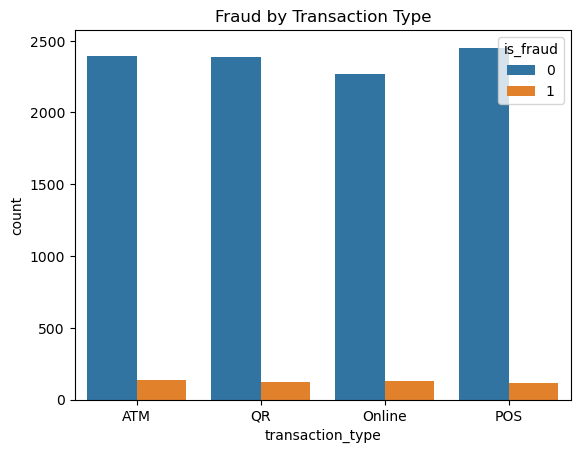

In [16]:
sns.countplot(
    x='transaction_type',
    hue='is_fraud',
    data=df
)

plt.title("Fraud by Transaction Type")
plt.show()

In [17]:
df.groupby('is_fraud')[['amount',
                        'device_risk_score',
                        'ip_risk_score']].mean()

,amount,device_risk_score,ip_risk_score
is_fraud,,,
0,100.277751,0.148290,0.149558
1,1657.577984,0.857951,0.851770


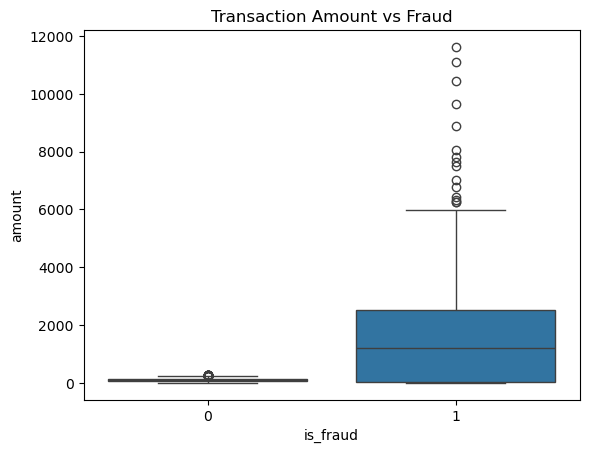

In [18]:
sns.boxplot(x='is_fraud', y='amount', data=df)

plt.title("Transaction Amount vs Fraud")
plt.show()

In [19]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'transaction_type',
        'merchant_category',
        'country'
    ],
    drop_first=True
)

df_encoded.head()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud,transaction_type_Online,transaction_type_POS,transaction_type_QR,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_FR,country_NG,country_TR,country_UK,country_US
0,9608,363,4922.587542,12,0.992347,0.947908,1,False,False,False,False,False,False,True,False,False,True,False,False
1,456,692,48.018303,21,0.168571,0.224057,0,False,False,True,False,True,False,False,False,False,False,False,True
2,4747,587,136.881960,14,0.296127,0.125058,0,True,False,False,False,False,False,True,False,False,True,False,False
3,6934,445,80.534719,23,0.124801,0.159243,0,False,True,False,False,False,False,False,False,False,True,False,False
4,1646,729,120.041158,16,0.098129,0.027542,0,True,False,False,False,False,True,False,True,False,False,False,False


In [20]:
df_encoded.shape

(10000, 19)

In [21]:
x = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [23]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 18)
(2000, 18)
(8000,)
(2000,)


In [24]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)
y_pred = rf.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



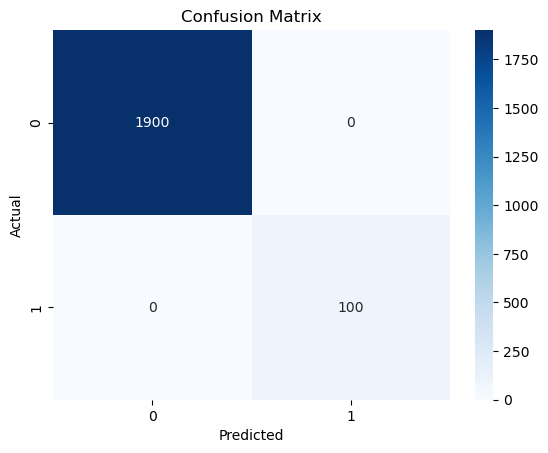

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV
param_grid={'n_estimators':[100,200,300],'max_depth':[10,20,30,None],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4],'max_features':['sqrt','log2']}
rf=RandomForestClassifier(random_state=42)
grid_search=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1,verbose=2)
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=2)

In [31]:
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best F1 Score:
1.0


In [32]:
best_rf=grid_search.best_estimator_
best_rf.fit(x_train,y_train)
print("Final Tuned Model is Ready")

Final Tuned Model is Ready


In [34]:
y_pred_best=best_rf.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred_best))
print("Precision:",precision_score(y_test,y_pred_best))
print("Recall:",recall_score(y_test,y_pred_best))
print("F1 Score:",f1_score(y_test,y_pred_best))
print("\nClassification Report\n")
print(classification_report(y_test,y_pred_best))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [35]:
from sklearn.metrics import roc_auc_score
y_prob=best_rf.predict_proba(x_test)[:,1]
roc_score=roc_auc_score(y_test,y_prob)
print("ROC-AUC Score:",roc_score)

ROC-AUC Score: 1.0


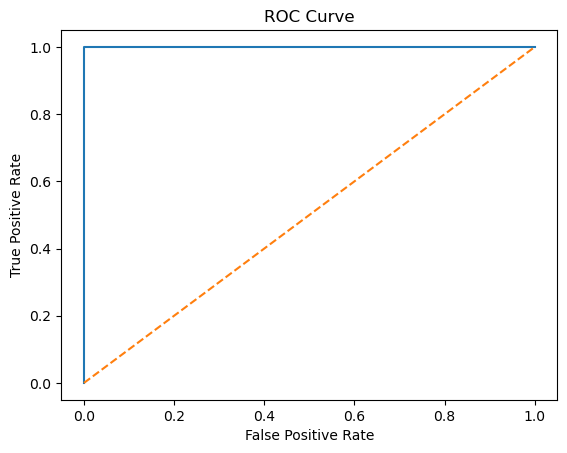

In [36]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [38]:
importance_df=pd.DataFrame({"Feature":x.columns,"Importance":best_rf.feature_importances_})
importance_df=importance_df.sort_values(by="Importance",ascending=False)
print(importance_df.head(15))

                      Feature  Importance
0              transaction_id    0.278837
4           device_risk_score    0.271260
5               ip_risk_score    0.244078
2                      amount    0.149151
3                        hour    0.047495
14                 country_NG    0.008754
1                     user_id    0.000267
15                 country_TR    0.000031
13                 country_FR    0.000028
6     transaction_type_Online    0.000024
11  merchant_category_Grocery    0.000024
16                 country_UK    0.000019
10     merchant_category_Food    0.000010
12   merchant_category_Travel    0.000010
7        transaction_type_POS    0.000006


In [39]:
import joblib 
joblib.dump(best_rf,"fraud_detection_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [40]:
joblib.dump(x.columns.tolist(),"feature_names.pkl")
print("Feature Names Saved")

Feature Names Saved


In [42]:
import os
print(os.path.exists("fraud_detection_model.pkl"))
print(os.path.exists("feature_names.pkl"))

True
True
